In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('Salary.csv')

# Check if it loaded correctly
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (35, 2)


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


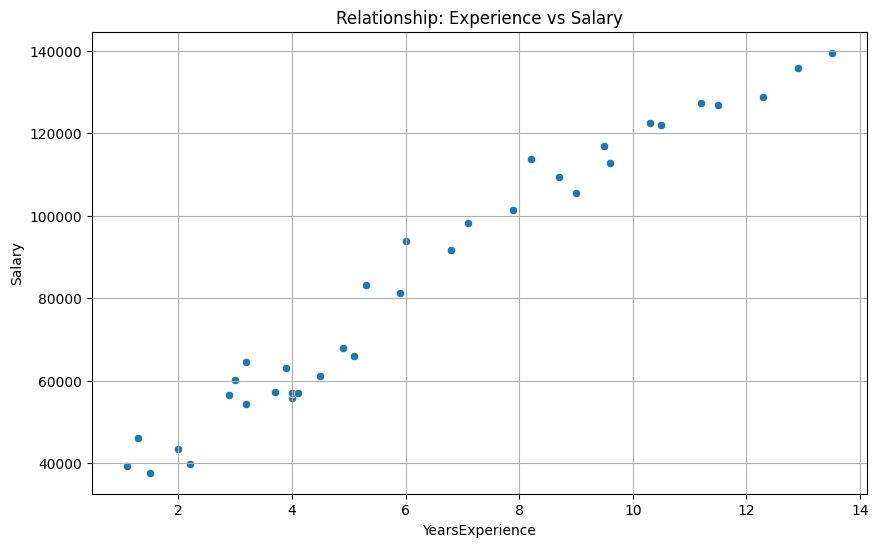

In [2]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='YearsExperience', y='Salary')
plt.title('Relationship: Experience vs Salary')
plt.grid(True)
plt.show()

In [3]:
# We use .values.reshape(-1, 1) because the model expects a 2D array for X
X = df[['YearsExperience']].values
y = df['Salary'].values

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 28
Testing samples: 7


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R2 Score (Accuracy): {r2:.4f}")

Mean Absolute Error: $6692.36
R2 Score (Accuracy): 0.8914


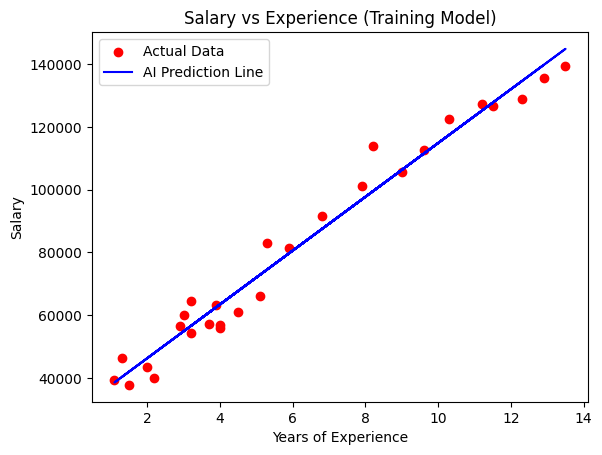

In [7]:
plt.scatter(X_train, y_train, color='red', label='Actual Data')
plt.plot(X_train, model.predict(X_train), color='blue', label='AI Prediction Line')
plt.title('Salary vs Experience (Training Model)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [8]:
def predict_salary(years):
    prediction = model.predict([[years]])
    print(f"A person with {years} years of experience is predicted to earn: ${prediction[0]:,.2f}")

# Try it out!
predict_salary(12)

A person with 12 years of experience is predicted to earn: $132,023.84


In [9]:
import joblib
joblib.dump(model, 'salary_model.pkl')
print("Model saved as salary_model.pkl")

Model saved as salary_model.pkl


In [10]:
!pip install -q gradio
import gradio as ui

def predict_salary_interface(years):
    # Ensure the input is in the correct format for the model
    pred = model.predict([[years]])
    return f"${pred[0]:,.2f}"

# Create the UI
app = ui.Interface(
    fn=predict_salary_interface,
    inputs=ui.Slider(0, 40, label="Years of Experience"),
    outputs="text",
    title="Salary Prediction System",
    description="Slide to select years of experience and see the predicted salary."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f47bfc56619dd5254.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
import pickle

# Save the model to a file
with open('salary_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model exported successfully!")

Model exported successfully!
